In [590]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from rembg import remove

In [591]:
def read_img(file_name):
    img = cv2.imread(file_name)
    img = cv2.resize(img, (250, 250))
    return img


In [592]:
def grayscale(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray

In [593]:
def remove_bg(gray):
    no_bg = remove(gray)
    mask = np.bool(no_bg[:,:,3])
    no_bg = no_bg[:,:,0]
    return no_bg, mask

In [594]:
def blur(img, k,sigma):
    return cv2.GaussianBlur(img, k, sigma)


In [595]:
def eddy_edge(img,mask,sigma):

    v = np.median(img[mask])
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))

    edges = cv2.Canny(img, lower, upper)
    return edges


In [596]:
def select_cnt(edges, N):
    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    contour_lengths = [(cnt, cv2.arcLength(cnt, closed=False)) for cnt in contours]
    contour_lengths.sort(key=lambda x: x[1], reverse=True)
    top_contours = [cnt for cnt, length in contour_lengths[:N]]
    filtered = np.zeros_like(edges)
    cv2.drawContours(filtered, top_contours, -1, 255, 1)
    return filtered, top_contours

In [597]:
def dilate(img, k):

    """
    # Use a longer kernel to elongate
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))

    # Apply closing
    elongated = cv2.morphologyEx(filtered, cv2.MORPH_CLOSE, kernel)

    """
    # Create a kernel (structuring element)
    # (5,1) elongates horizontally, (1,5) vertically
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, k)

    # Apply dilation
    elongated = cv2.dilate(img, kernel, iterations=1)

    return elongated


In [598]:
def elipsoid(img, cnt):
    output = np.zeros_like(img)
    for cnt in cnt:
        if len(cnt) >= 5: 
            ellipse = cv2.fitEllipse(cnt)
            cv2.ellipse(output, ellipse, 255, 1)
    return output

In [ ]:
for i in range(100):

    img=read_img(f'train_raw/owl_{(i+1)}.jpg')
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = grayscale(img)
    no_bg, mask = remove_bg(gray)
    blurred = blur(no_bg,(5,5),1.4)
    edges = eddy_edge(blurred,mask,0.3)
    filtered,_ = select_cnt(edges,20)
    elongated = blur(filtered,(15,15),7)# dilate(filtered,(3,3)) #
    filtered_1,cnt = select_cnt(elongated,2)
    output = elipsoid(filtered_1,cnt)


    images = [output, filtered_1, elongated, filtered, edges, blurred, no_bg, gray, img_rgb]
    fig, axes = plt.subplots(1, 9, figsize=(22, 4))
    axes = axes.flatten()

    for ax, img in zip(axes, images):
        ax.imshow(img, cmap='gray')
        ax.axis('off')  # hide axes

    plt.title(f'owl_{(i+1)}.jpg')
    plt.tight_layout()
    plt.show()



[ WARN:0@106199.863] global loadsave.cpp:278 findDecoder imread_('owl_1.jpg'): can't open/read file: check file path/integrity


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


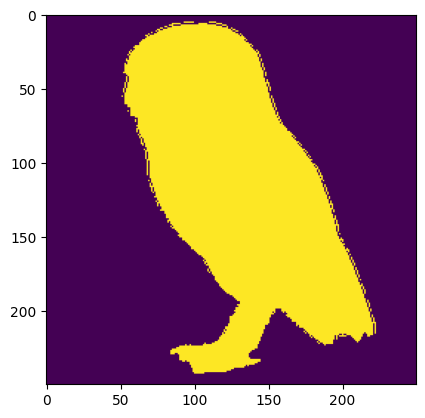

In [600]:
a =plt.imshow(mask)